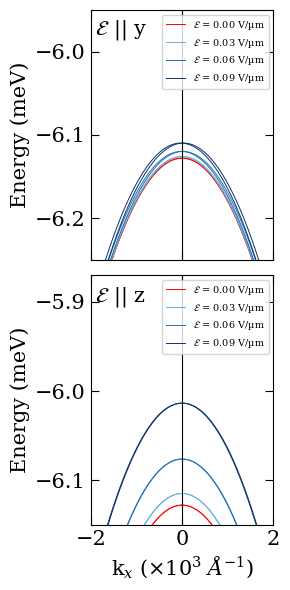

In [1]:
"""
It generates 4 plots  in a 2X2 grid layout. The top two plots show the top valance bands and bottom conduction bands in meV for E || Y and 
the bottom two plots show the same for E || Z. Each plot contains multiple curves representing different electric field strengths, 
with a color gradient from blue to red indicating increasing field strength. The x-axis represents the wave vector kx in 1/Å, 
while the y-axis represents energy in eV. The plots include reference lines for E=0 and a vertical dashed line at a specific k-point. 
The overall layout is adjusted for clarity, and the final figure is saved as both PNG and PDF files.
"""

import numpy as np
import matplotlib.pyplot as plt

# ======= PARAMETERS =======
size = 100
Ny = Nz = size
NN = Ny * Nz
Nband = 10
nk = 51
a = 20.0  # Å
kpoints = np.linspace(-0.002, 0.002, nk, endpoint=True)*1000
kpoints0 = np.linspace(-0.01, 0.01, 201, endpoint=True)*1000

eval_array_E0 = np.loadtxt(f"band_data_y_E0.000_size{size}_nk{nk}.dat")
efields_um = np.arange(0.03,0.12,0.03)

# efields_um = np.array([0.05])

# Colormap from blue → red
cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(efields_um)))

# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [3, 6],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

eval_array_E0 = np.loadtxt(f"band_data_y_E0.000_size{size}_nk{nk}.dat")



# ======= FUNCTION TO PLOT ON AXIS =======
def plot_bands(ax, direction, ylim, legend_loc, label, title):
    ax.plot(kpoints, eval_array_E0[:,0] * 1e3, color='red', lw=0.7, label = r"$\mathcal{E}$ = 0.00 V/µm")
    ax.plot(kpoints, eval_array_E0[:,1] * 1e3, color='red', lw=0.7)
    for idx, efield_um in enumerate(efields_um):
        efield_um = efields_um[idx]
        datafile = f"band_data_{direction}_E{efield_um:.3f}_size{size}_nk{nk}.dat"
        eval_array_E = np.loadtxt(datafile)
        # print(eval_array_E[:, 0]* 1e3)

        # Plot two nearby bands
        ax.plot(kpoints, eval_array_E[:, 0] * 1e3, color=colors[idx], lw=0.7)
        ax.plot(kpoints, eval_array_E[:, 1] * 1e3, color=colors[idx], lw=0.7,label=r"$\mathcal{E}$"f" = {efield_um:.2f} V/µm")
        

    ax.axvline(0, color='black', linestyle='-', lw=0.8)
    ax.axhline(0, color='black', linestyle='-', lw=0.8)
    # if ax == axs[0] or ax == axs[1]:
        # ax.axvline(kpoints[int((nk-1)/2 + (nk-1)/4)], color='g', linestyle='--', lw=0.8)
        
    # if ax == axs[0] or ax == axs[1]:
    #     ax.axvline(kpoints[int((nk-1)/2 - (nk-1)/10)], color='g', linestyle='--', lw=0.8)
    
    ax.set_xlim(-2, 2)
    ax.set_ylim(*ylim)
    ax.set_xticks([-2, 0, 2])
    ax.tick_params(direction='in', length=6, width=0.8, colors='k',
                   bottom=True, top=True, left=True, right=True, labelsize=15)
    ax.set_ylabel('Energy (meV)', fontsize=15)
    # ax.set_title(title, fontsize=15)
    ax.legend(loc='upper right', ncol=1, fontsize=7)

#---------------------------------------------
#  vertical layout: 2 rows, 1 column
#---------------------------------------------
# ======= CREATE FIGURE (2×1) =======
fig, axs = plt.subplots(2, 1, sharex=True)
plt.subplots_adjust(wspace=0.5, hspace=0.5)

# 1️ Field along Y — Valence
plot_bands(axs[0], 'y',  (-6.25,-5.95), 'lower left', 'a', 'Top VB (E‖Y)')
axs[0].text(-1.9,-5.98,r"$\mathcal{E}$ || y", fontsize = 15)

# 3️ Field along Z — Valence
plot_bands(axs[1], 'z', (-6.15,-5.87), 'lower left', 'c', 'Top VB (E‖Z)')
axs[1].text(-1.9,-5.9,r"$\mathcal{E}$ || z", fontsize = 15)
axs[1].set_xlabel(r'k$_x$ ($\times$10$^3$ $\AA$$^{-1}$)', fontsize=15)
plt.tight_layout()
# ======= SAVE =======
plt.savefig("bands_electrci_field_vertical.png", dpi = 300)
plt.savefig("bands_electrci_field_vertical.pdf")
plt.show()


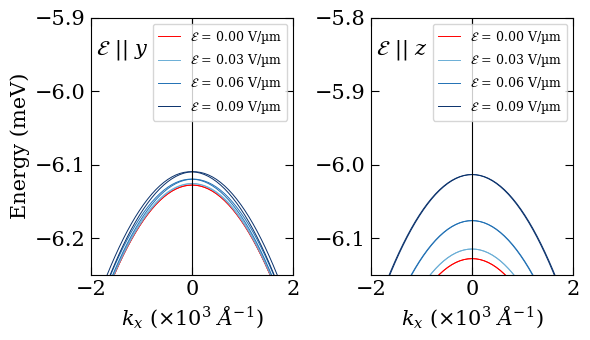

In [2]:

#%%
#---------------------------------------------
#  horizontal layout: 1 row, 2 columns
#---------------------------------------------

# ======= CREATE FIGURE (1×2) =======
fig, axs = plt.subplots(1, 2, figsize=(6, 3.5))

plt.subplots_adjust(wspace=0.3, hspace=0.0)

# 1️ Field along Y — Valence (LEFT)
plot_bands(axs[0], 'y',  (-6.25,-5.9), 'lower left', 'a', 'Top VB (E‖Y)')
axs[0].text(-1.9, -5.95, r"$\mathcal{E}$ || $y$", fontsize=15)

# 2️ Field along Z — Valence (RIGHT)
plot_bands(axs[1], 'z', (-6.15,-5.8), 'lower left', 'c', 'Top VB (E‖Z)')
axs[1].text(-1.9, -5.85, r"$\mathcal{E}$ || $z$", fontsize=15)
# axs[1].text(-3.9, -5.85, "(b)", fontsize=15)

# X label only once (centered visually)
axs[0].set_xlabel(r'$k_x$ ($\times$10$^3$ $\AA$$^{-1}$)', fontsize=15)
axs[1].set_xlabel(r'$k_x$ ($\times$10$^3$ $\AA$$^{-1}$)', fontsize=15)
axs[1].set_ylabel("")
axs[0].legend(fontsize=9, loc="best", handlelength=1.8)
axs[1].legend(fontsize=9, loc="best", handlelength=1.8)


plt.tight_layout()

# ======= SAVE =======
plt.savefig("bands_electrci_field_horizontal.png", dpi = 300)
plt.savefig("bands_electrci_field_horizontal.pdf")
plt.show()